# Exploratory Data Analysis (EDA) on Retail Sales Dataset

## Oasis Infobyte Data Analytics Internship

### Task 1: EDA on Retail Sales Data

### Objective
The objective of this project is to perform Exploratory Data Analysis (EDA) on a retail sales dataset to uncover sales trends, customer purchasing behavior, product performance, and actionable business insights. The analysis uses Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn to clean, explore, and visualize the data.

### Dataset
Retail Sales Dataset

### Tools & Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook (VS Code)

In [2]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore warning messages
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option('display.max_columns', None)

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [3]:
# Load the dataset
df = pd.read_csv("retail_sales_dataset.csv")
print(" Dataset loaded successfully!")

# Display the first 5 rows
df.head()

 Dataset loaded successfully!


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
# Shape of the dataset

print("="*50)
print("DATASET SHAPE")
print("="*50)

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

DATASET SHAPE
Number of Rows    : 1000
Number of Columns : 9


In [5]:
# Display all column names

print(df.columns.tolist())

['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']


In [6]:
# Display first five records

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [7]:
# Display last five records

df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [8]:
# Display random records

df.sample(5, random_state=42)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
521,522,2023-01-01,CUST522,Male,46,Beauty,3,500,1500
737,738,2023-04-25,CUST738,Male,41,Clothing,2,50,100
740,741,2023-11-30,CUST741,Male,48,Clothing,1,300,300
660,661,2023-07-16,CUST661,Female,44,Clothing,4,25,100
411,412,2023-09-16,CUST412,Female,19,Electronics,4,500,2000


In [9]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 100.2 KB


In [10]:
# Check missing values

missing_values = df.isnull().sum()

missing_values

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [11]:
# Display missing values in a cleaner format

missing_values = df.isnull().sum().to_frame(name="Missing Values")

missing_values

,Missing Values
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


# Duplicate Value Analysis

Duplicate records can affect data analysis by introducing bias and inaccurate results. Therefore, we check whether duplicate transactions exist in the dataset.

In [14]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print(f"Number of Duplicate Records: {duplicate_count}")

Number of Duplicate Records: 0


#Descriptive Statistics

Descriptive statistics summarize the numerical features of the dataset, including measures such as count, mean, standard deviation, minimum, maximum, and quartiles.

In [15]:
# Summary Statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Transaction ID,1000.0,500.500,288.819436,1.0,250.75,500.5,750.25,1000.0
Age,1000.0,41.392,13.681430,18.0,29.00,42.0,53.00,64.0
Quantity,1000.0,2.514,1.132734,1.0,1.00,3.0,4.00,4.0
Price per Unit,1000.0,179.890,189.681356,25.0,30.00,50.0,300.00,500.0
Total Amount,1000.0,456.000,559.997632,25.0,60.00,135.0,900.00,2000.0


In [16]:
# Statistical Summary

statistics = pd.DataFrame({
    "Mean": df.mean(numeric_only=True),
    "Median": df.median(numeric_only=True),
    "Mode": df.mode(numeric_only=True).iloc[0],
    "Standard Deviation": df.std(numeric_only=True)
})

statistics

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


# Feature Engineering

Feature engineering involves creating new features from existing columns to improve data analysis and visualization.# Convert Date column to datetime format


In [17]:
# Convert Date column to datetime format

df['Date'] = pd.to_datetime(df['Date'])

# Verify the datatype
df['Date'].dtype

dtype('<M8[us]')

In [18]:
# Create new date-related features

df['Month'] = df['Date'].dt.month
df['Month Name'] = df['Date'].dt.month_name()
df['Quarter'] = df['Date'].dt.quarter
df['Day Name'] = df['Date'].dt.day_name()

# Display sample data
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Month Name,Quarter,Day Name
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,November,4,Friday
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,February,1,Monday
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,January,1,Friday
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5,May,2,Sunday
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5,May,2,Saturday


In [19]:
# Create Age Groups

bins = [18, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

df[['Age', 'Age Group']].head()

,Age,Age Group
0,34,26-35
1,26,26-35
2,50,46-55
3,37,36-45
4,30,26-35


In [20]:
# Display updated dataset

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Month Name,Quarter,Day Name,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,November,4,Friday,26-35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,February,1,Monday,26-35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,January,1,Friday,46-55
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5,May,2,Sunday,36-45
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5,May,2,Saturday,26-35


# Visualization Phase

Data visualization is one of the most important steps in Exploratory Data Analysis (EDA). It helps transform raw data into meaningful graphical representations, making it easier to identify patterns, trends, relationships, and anomalies.

In this phase, various visualizations will be created to analyze customer demographics, product categories, sales performance, and purchasing behavior. Each visualization will be followed by a brief observation and business insight to support data-driven decision-making.

The visualizations included in this project are:

- Sales Distribution
- Age Distribution
- Gender Distribution
- Product Category Distribution
- Monthly Sales Trend
- Quarterly Sales Trend
- Revenue by Product Category
- Quantity Sold by Product Category
- Revenue by Gender
- Spending by Age Group
- Correlation Heatmap
- Average Transaction Value
- Sales by Day of the Week
- Additional Business Insight Visualization

## 1 Sales Distribution

This visualization shows the distribution of transaction amounts across all retail sales. It helps identify whether most transactions are of low, medium, or high value and provides an understanding of customer spending patterns.

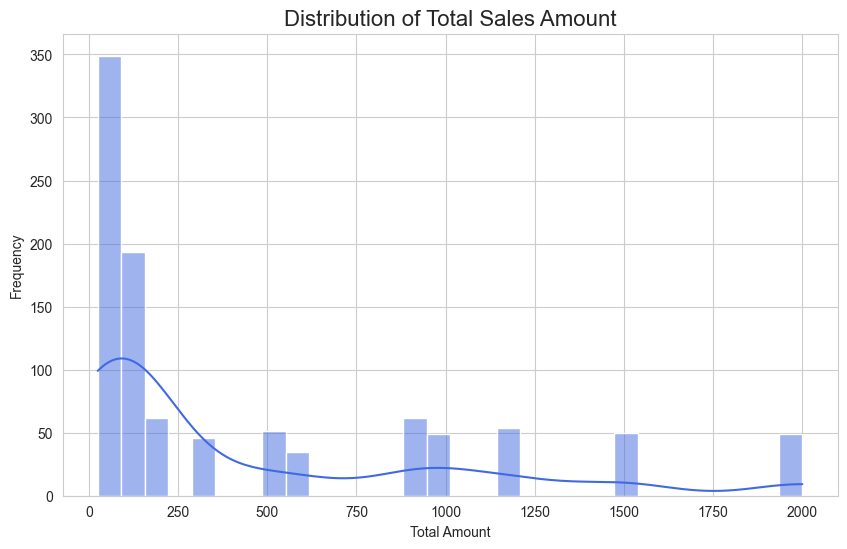

In [21]:
# ==========================================
# Sales Distribution
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='Total Amount',
    bins=30,
    kde=True,
    color='royalblue'
)

plt.title("Distribution of Total Sales Amount", fontsize=16)
plt.xlabel("Total Amount")
plt.ylabel("Frequency")

plt.show()

##  2 Customer Age Distribution

This visualization shows the distribution of customers across different ages, helping identify the dominant customer age groups.

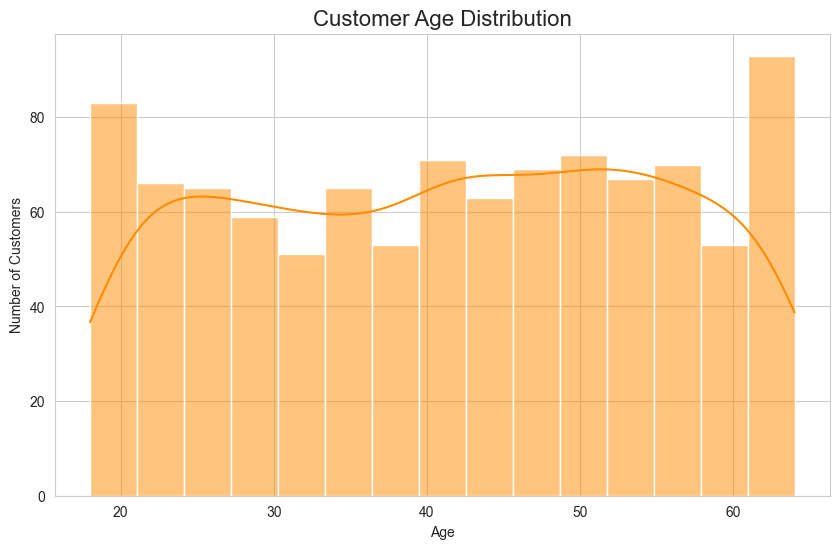

In [22]:
# ==========================================
# Age Distribution
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='Age',
    bins=15,
    kde=True,
    color='darkorange'
)

plt.title("Customer Age Distribution", fontsize=16)
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

## 3 Gender Distribution

This visualization illustrates the distribution of customers based on gender. It helps understand the composition of the customer base and identify whether purchasing behavior varies across different customer groups.

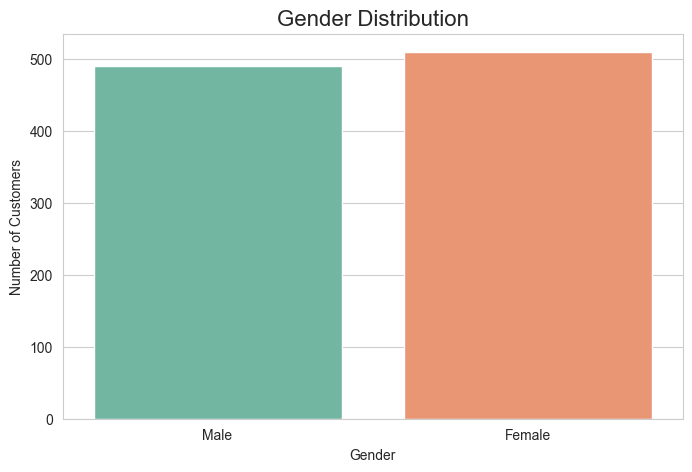

In [23]:
# ==========================================
# Gender Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Gender',
    palette='Set2'
)

plt.title("Gender Distribution", fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

## 4 Product Category Distribution

This visualization displays the distribution of transactions across different product categories. It helps identify the most frequently purchased product categories.

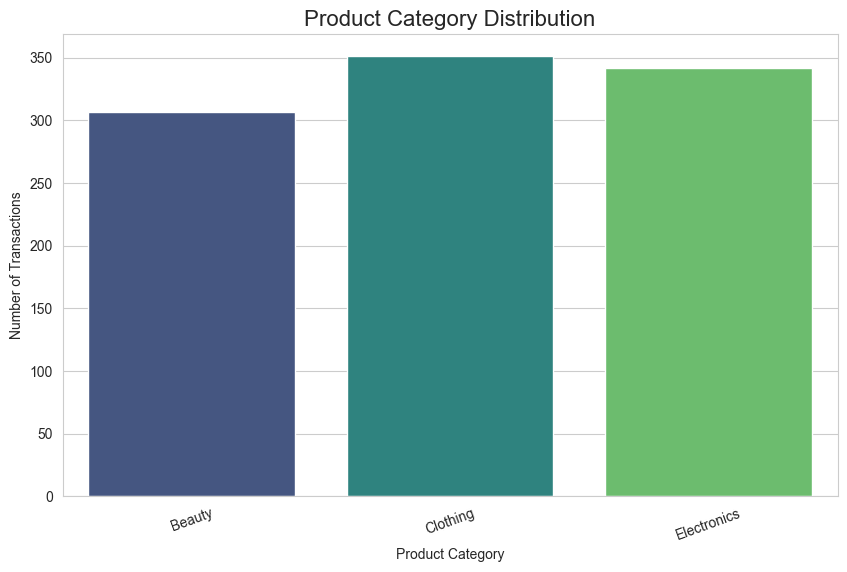

In [24]:
# ==========================================
# Product Category Distribution
# ==========================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='Product Category',
    palette='viridis'
)

plt.title("Product Category Distribution", fontsize=16)
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=20)

plt.show()

## 5 Monthly Sales Trend

This visualization analyzes the total sales generated each month. Understanding monthly sales trends helps identify seasonal patterns, peak sales periods, and months with lower business performance.

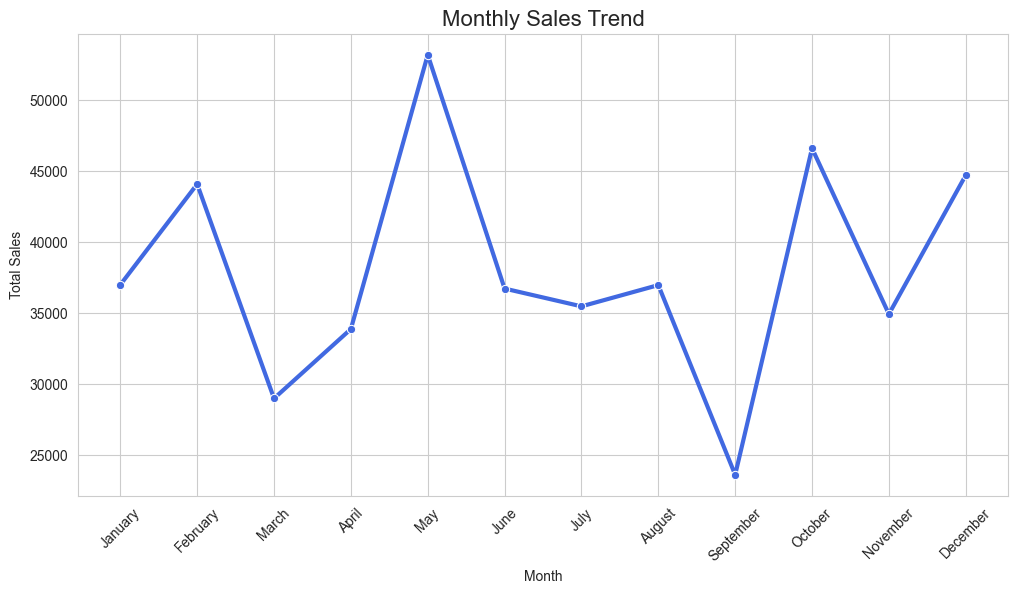

In [25]:
# ==========================================
# Monthly Sales Trend
# ==========================================

monthly_sales = df.groupby('Month Name')['Total Amount'].sum()

# Arrange months in calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker='o',
    linewidth=3,
    color='royalblue'
)

plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

## 6 Quarterly Sales Trend

Quarterly analysis provides a broader view of sales performance by grouping transactions into four quarters of the year.

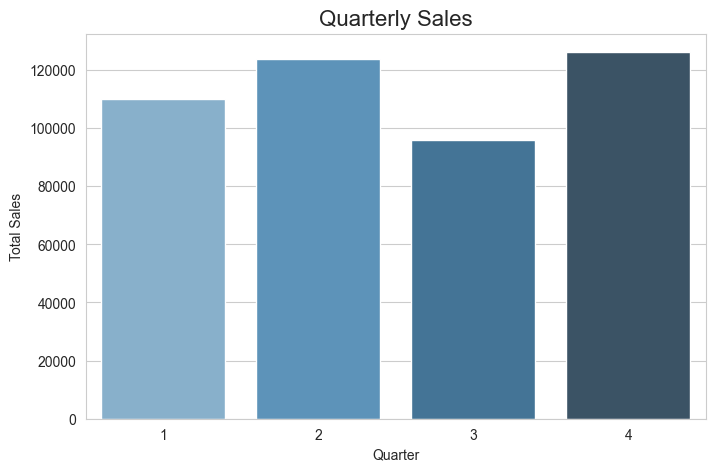

In [26]:
# ==========================================
# Quarterly Sales Trend
# ==========================================

quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=quarterly_sales.index.astype(str),
    y=quarterly_sales.values,
    palette='Blues_d'
)

plt.title("Quarterly Sales", fontsize=16)
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.show()

## 7 Revenue by Product Category

This visualization compares the total revenue generated by each product category, helping identify the categories that contribute the most to overall sales.

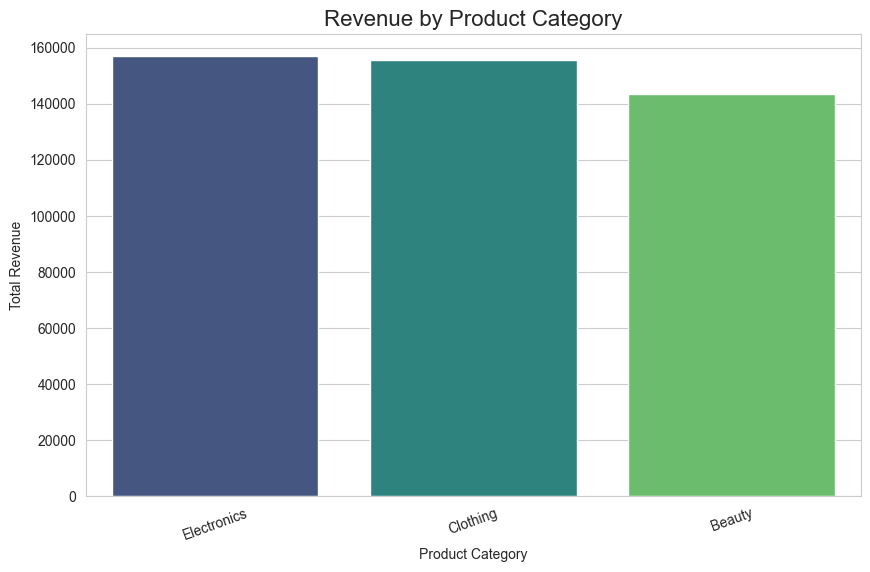

In [27]:
# ==========================================
# Revenue by Product Category
# ==========================================

category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    palette='viridis'
)

plt.title("Revenue by Product Category", fontsize=16)
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=20)

plt.show()

## 8 Quantity Sold by Product Category

This visualization compares the total quantity of products sold across different product categories. It helps identify which categories are purchased most frequently by customers.

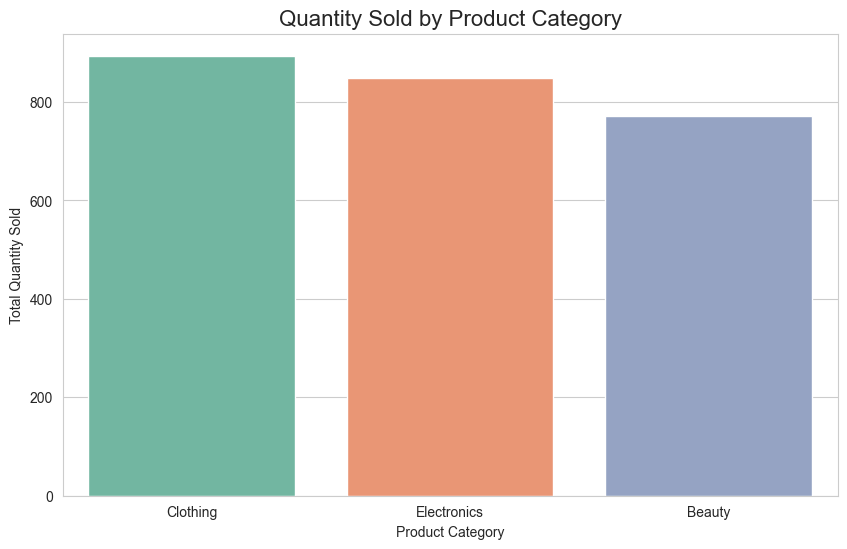

In [28]:
# ==========================================
# Quantity Sold by Product Category
# ==========================================

quantity_category = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=quantity_category.index,
    y=quantity_category.values,
    palette='Set2'
)

plt.title("Quantity Sold by Product Category", fontsize=16)
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")

plt.show()

## 9 Revenue by Gender

This visualization compares the total revenue generated by male and female customers to understand purchasing behavior across genders.

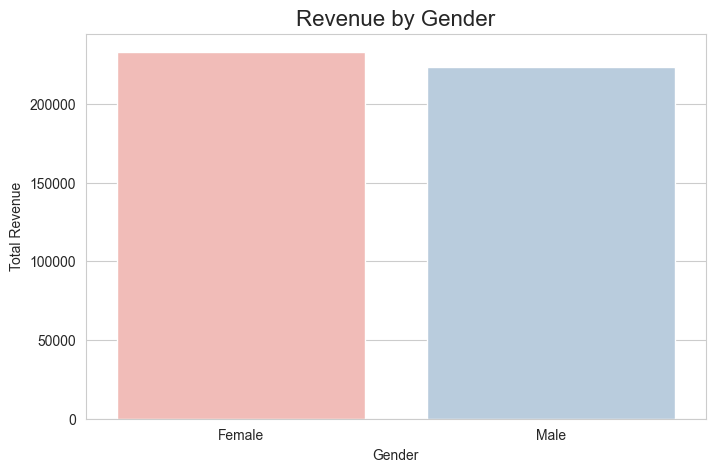

In [29]:
# ==========================================
# Revenue by Gender
# ==========================================

gender_sales = df.groupby('Gender')['Total Amount'].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=gender_sales.index,
    y=gender_sales.values,
    palette='Pastel1'
)

plt.title("Revenue by Gender", fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Total Revenue")

plt.show()

## 10 Spending by Age Group

This visualization examines the total spending of different customer age groups to identify the most valuable customer segments.

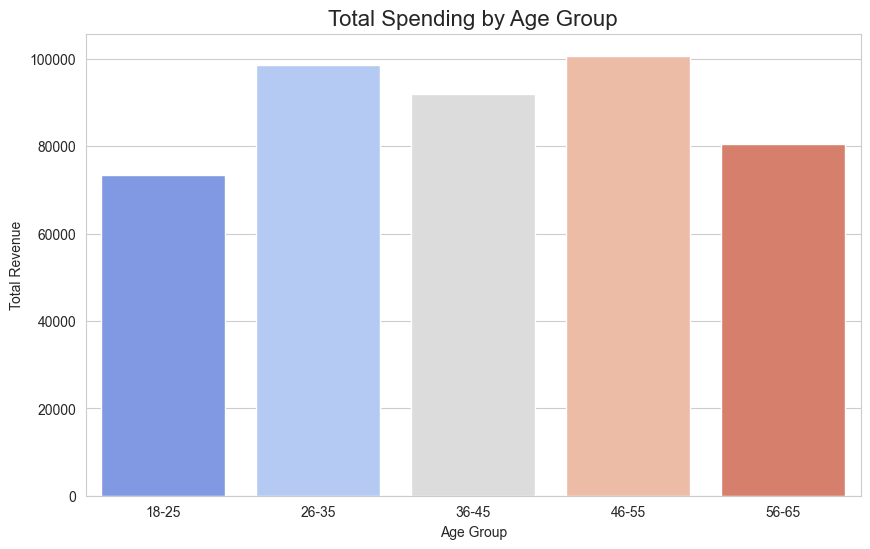

In [30]:
# ==========================================
# Spending by Age Group
# ==========================================

age_group_sales = df.groupby('Age Group')['Total Amount'].sum()

plt.figure(figsize=(10,6))

sns.barplot(
    x=age_group_sales.index,
    y=age_group_sales.values,
    palette='coolwarm'
)

plt.title("Total Spending by Age Group", fontsize=16)
plt.xlabel("Age Group")
plt.ylabel("Total Revenue")

plt.show()

## 11 Correlation Heatmap

A correlation heatmap displays the relationships between numerical variables. It helps identify positive and negative correlations that can provide valuable business insights.

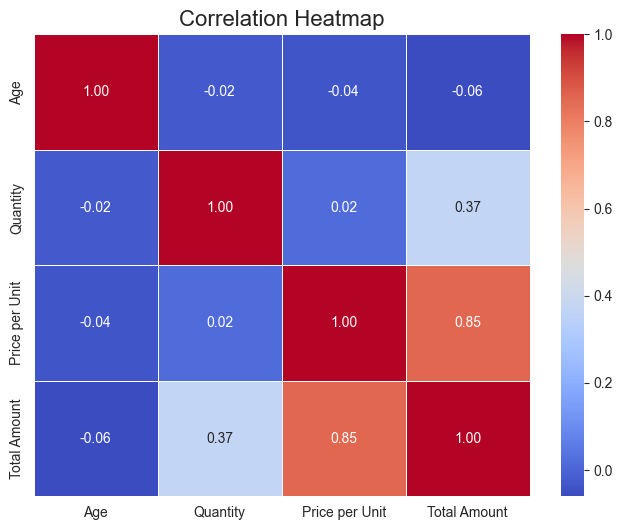

In [31]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(8,6))

corr = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt='.2f'
)

plt.title("Correlation Heatmap", fontsize=16)

plt.show()

## 12 Average Transaction Value by Product Category

This visualization compares the average transaction value across different product categories, helping identify categories with higher-value purchases.

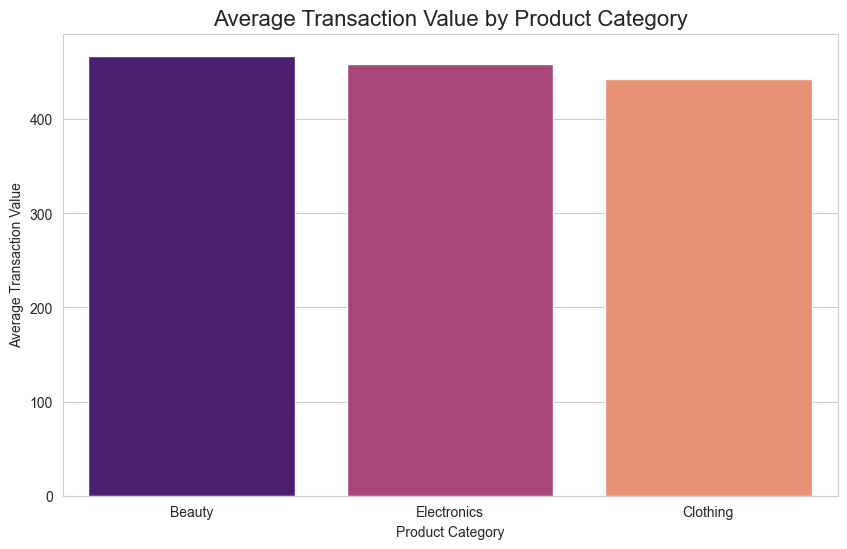

In [32]:
# ==========================================
# Average Transaction Value by Product Category
# ==========================================

avg_sales = df.groupby('Product Category')['Total Amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=avg_sales.index,
    y=avg_sales.values,
    palette='magma'
)

plt.title("Average Transaction Value by Product Category", fontsize=16)
plt.xlabel("Product Category")
plt.ylabel("Average Transaction Value")

plt.show()

# 11>Key Business Insights

Based on the exploratory data analysis, the following key business insights were identified:

1. Customer purchasing behavior varies across different product categories, with some categories generating significantly higher revenue than others.

2. Monthly and quarterly sales analysis reveals fluctuations in sales performance, indicating seasonal purchasing trends.

3. Customer demographics such as age group and gender influence purchasing behavior and overall revenue generation.

4. Certain product categories contribute more to total sales as well as transaction volume, making them the primary revenue drivers.

5. Correlation analysis indicates the relationships between numerical variables such as quantity purchased, unit price, and total transaction amount.

# 12.Business Recommendations

Based on the findings from the analysis, the following recommendations are proposed:

### 1. Focus on High-Performing Categories
Increase inventory and promotional efforts for product categories that generate the highest revenue.

### 2. Target High-Spending Customer Segments
Develop personalized marketing campaigns for customer groups that contribute the highest sales.

### 3. Seasonal Sales Planning
Plan inventory, staffing, and promotional campaigns based on monthly and quarterly sales trends.

### 4. Improve Low-Performing Categories
Analyze customer preferences and introduce promotional offers or pricing strategies to improve sales in underperforming categories.

### 5. Data-Driven Decision Making
Use customer purchase behavior and sales trends to support future business planning and strategic decision-making.

# 13.Conclusion

This project successfully performed Exploratory Data Analysis (EDA) on a retail sales dataset using Python. The analysis included data inspection, descriptive statistics, feature engineering, and multiple visualizations to understand customer behavior, product performance, and sales trends.

The insights obtained from this analysis can help businesses make informed decisions regarding inventory management, marketing strategies, customer segmentation, and revenue optimization.

Overall, the project demonstrates how data analytics can transform raw retail data into meaningful business insights that support strategic decision-making.

# Thank You

**Project Completed as part of the Oasis Infobyte Data Analytics Internship**

**Task 1:** Exploratory Data Analysis (EDA) on Retail Sales Data

**Developed by:** Jayshri Borude

Thank you for reviewing this project.